In [1]:
# PASSO 1: Instalar e Importar Bibliotecas

# O 'yfinance' é uma biblioteca que nos permite descarregar
# dados históricos do mercado de ações (Yahoo Finance) facilmente.
!pip install yfinance

# Agora, importamos as bibliotecas que vamos usar
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

/tmp/ipython-input-45849846.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados = yf.download(ticker_simbolo, start=data_inicio, end=data_fim)
[*********************100%***********************]  1 of 1 completed


---- Primeiros 5 Registos dos Dados ----
Price           Close       High        Low       Open    Volume
Ticker          GOOGL      GOOGL      GOOGL      GOOGL     GOOGL
Date                                                            
2015-01-02  26.296133  26.606492  26.213203  26.447587  26480000
2015-01-05  25.795090  26.218669  25.710177  26.176956  41182000
2015-01-06  25.158482  25.881990  25.104354  25.846734  54456000
2015-01-07  25.084490  25.399318  25.010005  25.372504  46918000
2015-01-08  25.171890  25.201187  24.581461  24.903739  73054000


---- Visualização do Preço de Fecho ----


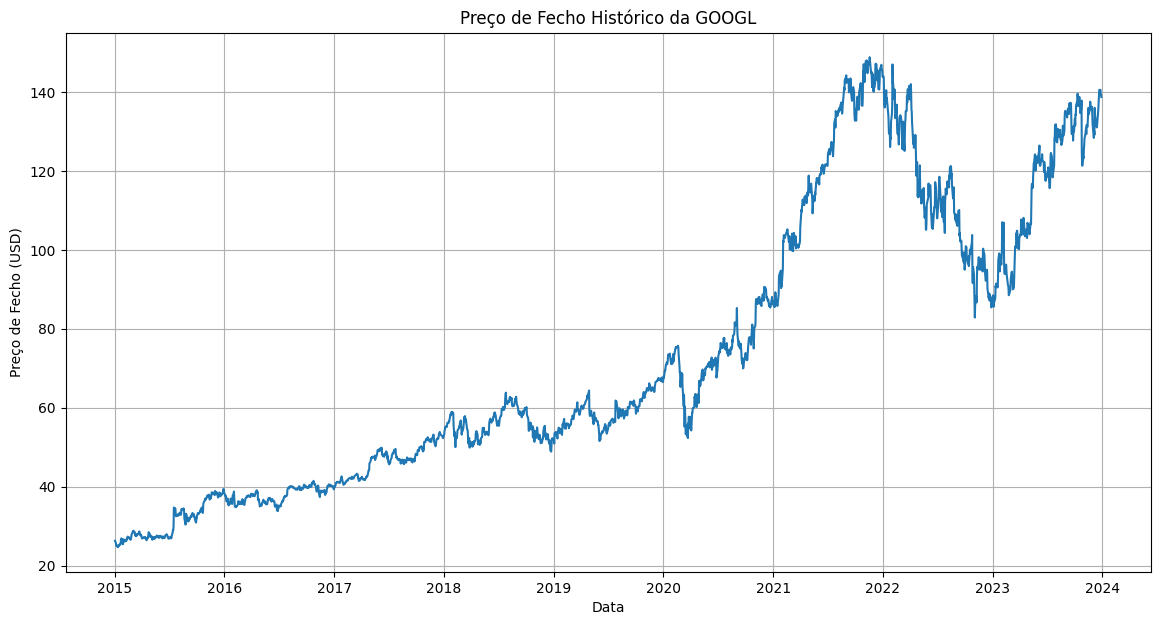

In [2]:
# PASSO 2: Obter os Dados

# Vamos escolher a ação que queremos prever
ticker_simbolo = 'GOOGL'
data_inicio = '2015-01-01'
data_fim = '2023-12-31'

# Usar o yfinance para descarregar os dados
dados = yf.download(ticker_simbolo, start=data_inicio, end=data_fim)

# Vamos ver os primeiros 5 registos para entender os dados
print("---- Primeiros 5 Registos dos Dados ----")
print(dados.head())
print("\n")

# Para este projeto, estamos interessados apenas no preço de "Fecho" (Close)
dados_fecho = dados[['Close']]

# Vamos visualizar os dados que descarregámos
print("---- Visualização do Preço de Fecho ----")
plt.figure(figsize=(14, 7))
plt.title(f'Preço de Fecho Histórico da {ticker_simbolo}')
plt.plot(dados_fecho['Close'])
plt.xlabel('Data')
plt.ylabel('Preço de Fecho (USD)')
plt.grid(True)
plt.show()

In [3]:
# PASSO 3.A: Normalização e Divisão dos Dados

# 1. Normalização
# Criamos o 'scaler' que vai transformar os preços para uma escala entre 0 e 1.
scaler = MinMaxScaler(feature_range=(0, 1))

# Convertemos os dados de 'fecho' (que são um DataFrame) para um array numpy
# e aplicamos a normalização.
dados_fecho_array = dados_fecho.values
dados_escalados = scaler.fit_transform(dados_fecho_array)

# 2. Divisão Treino/Teste
# Para séries temporais, NUNCA podemos baralhar os dados.
# Temos de treinar com os dados antigos e testar com os dados novos.
# Vamos usar 80% dos dados para treino e os restantes 20% para teste.

tamanho_treino = int(len(dados_escalados) * 0.80)
tamanho_teste = len(dados_escalados) - tamanho_treino

# Separamos os dados
dados_treino_escalados = dados_escalados[0:tamanho_treino, :]
dados_teste_escalados = dados_escalados[tamanho_treino:len(dados_escalados), :]

print(f"Total de dados: {len(dados_escalados)}")
print(f"Dados de Treino (80%): {len(dados_treino_escalados)}")
print(f"Dados de Teste (20%): {len(dados_teste_escalados)}")

Total de dados: 2264
Dados de Treino (80%): 1811
Dados de Teste (20%): 453


In [4]:
# PASSO 3.B: Função Auxiliar para Criar Sequências

# Esta função vai criar os "blocos" de dados para a LSTM
# data: O conjunto de dados (ex: dados_treino_escalados)
# lookback_periodo: Quantos dias queremos "olhar para trás" para fazer a previsão

def criar_sequencias(data, lookback_periodo):
    X_data = [] # Lista para os inputs (ex: os 60 dias anteriores)
    y_data = [] # Lista para os outputs (ex: o 61º dia)

    # Iteramos sobre os dados
    # Começamos no índice 'lookback_periodo' porque precisamos de 60 dias *antes* dele
    for i in range(lookback_periodo, len(data)):

        # X é a sequência de 'lookback_periodo' dias
        # (do dia i-60 até ao dia i-1)
        X_data.append(data[i-lookback_periodo:i, 0])

        # y é o dia que queremos prever (o dia i)
        y_data.append(data[i, 0])

    # Convertemos as listas para arrays numpy
    return np.array(X_data), np.array(y_data)

In [5]:
# PASSO 3.C: Criar os Conjuntos Finais e Fazer 'Reshape'

# Vamos definir que a nossa LSTM vai olhar para os últimos 60 dias
# para prever o próximo.
lookback_periodo = 60

# 1. Criar as sequências de treino
X_treino, y_treino = criar_sequencias(dados_treino_escalados, lookback_periodo)

# 2. Criar as sequências de teste
X_teste, y_teste = criar_sequencias(dados_teste_escalados, lookback_periodo)

# 3. Fazer o Reshape (Formato 3D)
# A LSTM do Keras espera dados num formato 3D:
# [n_amostras, n_timesteps, n_features]
#
# n_amostras: O número de "janelas" que criámos (ex: 2133)
# n_timesteps: O nosso 'lookback' (ex: 60 dias)
# n_features: O número de indicadores que estamos a usar.
#             (Estamos a usar só o preço de 'Fecho', então é 1)

X_treino = np.reshape(X_treino, (X_treino.shape[0], X_treino.shape[1], 1))
X_teste = np.reshape(X_teste, (X_teste.shape[0], X_teste.shape[1], 1))

# Vamos verificar os formatos (shapes)
print("---- Formato dos Dados de Treino ----")
print(f"X_treino shape: {X_treino.shape}") # (Amostras, 60, 1)
print(f"y_treino shape: {y_treino.shape}") # (Amostras,)
print("\n")
print("---- Formato dos Dados de Teste ----")
print(f"X_teste shape: {X_teste.shape}")   # (Amostras, 60, 1)
print(f"y_teste shape: {y_teste.shape}")   # (Amostras,)

---- Formato dos Dados de Treino ----
X_treino shape: (1751, 60, 1)
y_treino shape: (1751,)


---- Formato dos Dados de Teste ----
X_teste shape: (393, 60, 1)
y_teste shape: (393,)


In [6]:
# PASSO 4.A: Construir a Arquitetura da Rede

# Vamos usar um modelo 'Sequential', que é uma "pilha" linear de camadas.
model = Sequential()

# Camada 1: A nossa primeira camada LSTM
# units=50: O número de "neurónios de memória" na camada.
# return_sequences=True: Essencial. Como temos outra camada LSTM a seguir,
#                       esta camada tem de retornar a *sequência* completa.
# input_shape: Diz à camada o formato dos nossos dados de entrada (60 dias, 1 feature)
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_treino.shape[1], 1)))

# Adicionamos 'Dropout' para evitar "overfitting" (quando o modelo decora
# os dados de treino em vez de aprender os padrões).
model.add(Dropout(0.2)) # Desliga 20% dos neurónios aleatoriamente durante o treino

# Camada 2: Segunda camada LSTM
# return_sequences=False: Este é o default. Como é a *última* camada LSTM,
#                       ela só precisa de enviar o output do último dia.
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Camada 3: Uma camada 'Dense' (normal) para processar o output da LSTM
model.add(Dense(units=25))

# Camada 4: A camada de Saída
# units=1: A saída final. Queremos prever apenas 1 número (o preço do dia seguinte).
model.add(Dense(units=1))

# Vamos ver um resumo da nossa arquitetura
print("---- Resumo do Modelo ----")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


---- Resumo do Modelo ----


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# PASSO 4.B: Compilar e Treinar o Modelo

print("\n\n---- A Iniciar o Treino ----")

# 1. Compilar o Modelo
# optimizer='adam': O algoritmo que otimiza o modelo. 'adam' é o mais
#                   comum e eficiente para a maioria dos casos.
# loss='mean_squared_error': A "função de perda". Estamos a dizer ao modelo:
#                          "Tenta minimizar o erro quadrático médio".
#                          É o padrão para problemas de regressão (prever um número).
model.compile(optimizer='adam', loss='mean_squared_error')

# 2. Treinar o Modelo
# model.fit() é o comando que inicia o treino.
# epochs=50: O modelo vai "ver" o dataset de treino completo 50 vezes.
# batch_size=32: O modelo vai olhar para 32 "janelas" de 60 dias de cada vez
#                antes de atualizar os seus pesos.
# verbose=1: Mostra a barra de progresso do treino.
history = model.fit(
    X_treino,
    y_treino,
    epochs=50,
    batch_size=32,
    verbose=1
)

print("---- Treino Concluído ----")



---- A Iniciar o Treino ----
Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0301
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0022
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0017
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0019
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0017
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0013
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0013
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0012
Epoch 9/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0012
Epoch 10/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0011
Epoch 11/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0010
Epoch 12/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.8309e-04
Epoch 13/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.0137e-04
Epoch 14/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0010
Epoch 15/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8m

In [8]:
# PASSO 5.A: Fazer Previsões e Reverter a Escala

# 1. Pedir ao modelo para prever os dados de teste
previsoes_escaladas = model.predict(X_teste)

# 2. Reverter a escala das previsões
# O 'scaler' lembra-se da escala original (ex: min 20$, max 180$)
# e vai reverter os dados de (0-1) de volta para Dólares.
previsoes_reais = scaler.inverse_transform(previsoes_escaladas)

# 3. Reverter a escala dos dados reais de teste (para podermos comparar)
# O y_teste também estava na escala (0-1), temos de o reverter.
# Usamos .reshape(-1, 1) porque o scaler espera um array 2D.
y_teste_reais = scaler.inverse_transform(y_teste.reshape(-1, 1))

print("---- Previsões Concluídas ----")
print(f"Formato das previsões (reais): {previsoes_reais.shape}")
print(f"Formato do y_teste (reais): {y_teste_reais.shape}")
print("\n")
print("---- Exemplo de Previsão ----")
# Vamos ver a primeira previsão vs. o valor real
print(f"Previsão do Modelo (escalada): {previsoes_escaladas[0][0]:.4f}")
print(f"Previsão do Modelo (real): ${previsoes_reais[0][0]:.2f}")
print(f"Valor Real (real): ${y_teste_reais[0][0]:.2f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
---- Previsões Concluídas ----
Formato das previsões (reais): (393, 1)
Formato do y_teste (reais): (393, 1)


---- Exemplo de Previsão ----
Previsão do Modelo (escalada): 0.7298
Previsão do Modelo (real): $115.28
Valor Real (real): $116.39


---- A Gerar Gráfico Final ----


/tmp/ipython-input-3065565670.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados_plot_teste_com_previsoes['Previsoes'] = previsoes_reais


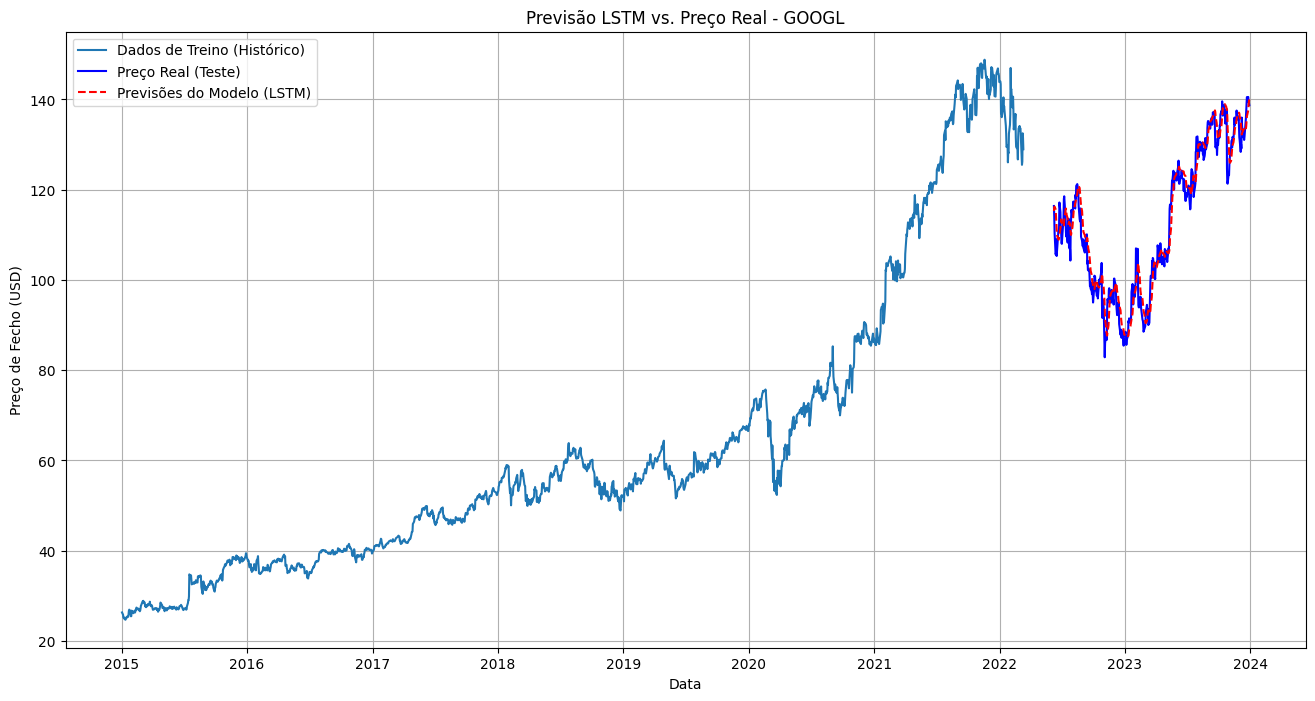

In [9]:
# PASSO 5.B: Visualizar os Resultados

print("---- A Gerar Gráfico Final ----")

# Para facilitar a visualização, vamos criar um DataFrame (tabela)
# com os dados de teste e as nossas previsões.

# 1. Separar os dados de treino e teste originais (com as datas)
tamanho_treino = int(len(dados_fecho) * 0.80)
lookback_periodo = 60 # O mesmo que usámos no Passo 3

# Tabela para os dados de treino
dados_plot_treino = dados_fecho[:tamanho_treino]

# Tabela para os dados de teste
dados_plot_teste = dados_fecho[tamanho_treino:]

# 2. Adicionar as previsões à tabela de teste
# As previsões não começam no primeiro dia de teste,
# mas sim 'lookback_periodo' dias depois (porque precisávamos de 60
# dias de dados para fazer a primeira previsão).
dados_plot_teste_com_previsoes = dados_plot_teste[lookback_periodo:]
dados_plot_teste_com_previsoes['Previsoes'] = previsoes_reais

# 3. Desenhar o gráfico
plt.figure(figsize=(16, 8))
plt.title(f'Previsão LSTM vs. Preço Real - {ticker_simbolo}')
plt.xlabel('Data')
plt.ylabel('Preço de Fecho (USD)')

# Plotar os 3 blocos
plt.plot(dados_plot_treino['Close'], label='Dados de Treino (Histórico)')
plt.plot(dados_plot_teste_com_previsoes['Close'], label='Preço Real (Teste)', color='blue')
plt.plot(dados_plot_teste_com_previsoes['Previsoes'], label='Previsões do Modelo (LSTM)', color='red', linestyle='--')

plt.legend()
plt.grid(True)
plt.show()